## Import all the necessary config files

In [13]:
#is python selected as the kernel?
#have you closed the parameters excel sheet?

from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import random

np.random.seed(42)
random.seed(42)

#if you get an error here you propoably didn't close the parameters excel sheet

In [ ]:
# model name to be included in file names later with the output_title function, creating an iteration subscript, e.g. Run_001
title = 'A1 Myrmidon base condition 12112025'

## Run the coral model

## Run simulation for n number of times and plot the total coral cover

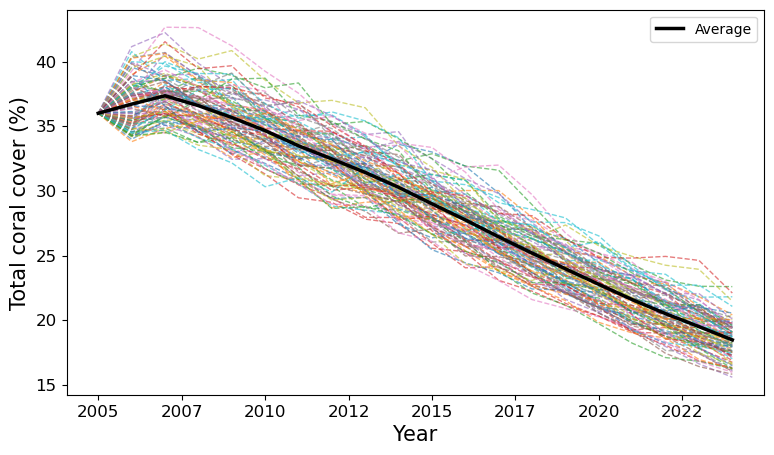

In [15]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

## Run the model through a number iterations for all parameters and export results

In [16]:
#setting seed to ensure repeatability of runs 

np.random.seed(42)
random.seed(42)

final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)
area_df.iloc[:, 2:] = (area_df.iloc[:, 2:] * 100).clip(upper=100)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

#Export tables to Excel
run_id = "Run_" + make_run_id(output_folder)               # e.g. '20250808_01'
fname  = f"{run_id}_all_results.xlsx" 

# Define the graph directory path
graph_dir_t = r'output/tables'# '20250808_01_all_results.xlsx'

# fname = '20250808_01_all_results.xlsx'  # if you need this
path = os.path.join(graph_dir_t, fname)

# FIX: Create the directory if it doesn't exist
os.makedirs(graph_dir_t, exist_ok=True)

path   = os.path.join(graph_dir_t, fname)

final_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_final.xlsx"), index=False)
population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population.xlsx"), index=False)
percentage_population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population_percentage.xlsx"), index=False)
area_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_area.xlsx"), index=False)

Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            6.000000         24.000000        6.000000   
1      1            5.084319         22.917771        9.347809   
2      2            4.479999         22.287293       10.000396   
3      3            3.934501         22.330509        9.458815   
4      4            3.525181         23.284375        9.969589   
..   ...                 ...               ...             ...   
15    15            0.799467         15.547850        5.840289   
16    16            0.672134         15.198358        5.122249   
17    17            0.523664         14.142576        4.771058   
18    18            0.386809         12.795049        4.271565   
19    19            0.246527         11.933978        4.421595   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               36.000000                80.300000                72.800000   
1               37.349899        

## Create plots for coral cover, benthic cover and rugosity based on the multiple iteration runs

In [17]:
from pprint import pprint
import pandas as pd

names = [
    'sediment_df',
    'sediment_years',
    'add_sedi_exp_per_year',
    'suspended',
    'deposited',
    'sedi_exp_growth_coeff',
    'sedi_exp_PCM_coeff'
]

def _print_var(name):
    g = globals()
    print(f"\n=== {name} ===")
    if name in g:
        val = g[name]
        try:
            if isinstance(val, pd.DataFrame):
                # show the dataframe (first rows) for readability
                display(val.head())
                return
        except Exception:
            pass
        pprint(val)
    else:
        print("NOT FOUND")

# If suspended/deposited are not defined but add_sedi_exp_per_year + year range exist, build them
if 'add_sedi_exp_per_year' in globals() and (('suspended' not in globals()) or ('deposited' not in globals())):
    if 'year_start' in globals() and 'year_end' in globals():
        years = list(range(year_start, year_end + 1))
        model_years = [y - year_start for y in years]
        suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
        deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]
        # attach to globals so the subsequent prints find them
        globals()['suspended'] = suspended
        globals()['deposited'] = deposited

for n in names:
    _print_var(n)


=== sediment_df ===


,Year,Month,Suspended_sediment,Deposited_sediment
0,2005,1,5,1
1,2005,2,5,1
2,2005,3,5,8
3,2005,4,5,8
4,2005,5,100,8



=== sediment_years ===
NOT FOUND

=== add_sedi_exp_per_year ===
{0: (380.0, 51.0),
 1: (380.0, 51.0),
 2: (380.0, 51.0),
 3: (380.0, 51.0),
 4: (380.0, 51.0),
 5: (380.0, 51.0),
 6: (380.0, 51.0),
 7: (380.0, 51.0),
 8: (380.0, 51.0),
 9: (380.0, 51.0),
 10: (380.0, 51.0),
 11: (380.0, 51.0),
 12: (380.0, 51.0),
 13: (380.0, 51.0),
 14: (380.0, 51.0),
 15: (380.0, 51.0),
 16: (380.0, 51.0),
 17: (380.0, 51.0),
 18: (380.0, 51.0),
 19: (380.0, 51.0)}

=== suspended ===
0.0

=== deposited ===
0.0

=== sedi_exp_growth_coeff ===
{'Branching': -0.00997, 'Foliose': -0.00272, 'Other': -0.00533}

=== sedi_exp_PCM_coeff ===
{'Branching': 0.00154, 'Foliose': 0.000724, 'Other': 0.001645}


In [18]:
from pprint import pprint

# Print `additional_sediment_exposure` if present; otherwise fall back to known variables
# (relies on `pprint` imported in another cell)

if 'additional_sediment_exposure' in globals():
    print("additional_sediment_exposure:")
    pprint(globals()['additional_sediment_exposure'])

else:
    print("additional_sediment_exposure not found and cannot be constructed from available data.")

additional_sediment_exposure:
{(0, 1): (0.0, 0.0),
 (0, 2): (0.0, 0.0),
 (0, 3): (0.0, 0.0),
 (0, 4): (0.0, 0.0),
 (0, 5): (95, 0.0),
 (0, 6): (95, 17),
 (0, 7): (95, 17),
 (0, 8): (95, 17),
 (0, 9): (0.0, 0.0),
 (0, 10): (0.0, 0.0),
 (0, 11): (0.0, 0.0),
 (0, 12): (0.0, 0.0),
 (1, 1): (0.0, 0.0),
 (1, 2): (0.0, 0.0),
 (1, 3): (0.0, 0.0),
 (1, 4): (0.0, 0.0),
 (1, 5): (95, 0.0),
 (1, 6): (95, 17),
 (1, 7): (95, 17),
 (1, 8): (95, 17),
 (1, 9): (0.0, 0.0),
 (1, 10): (0.0, 0.0),
 (1, 11): (0.0, 0.0),
 (1, 12): (0.0, 0.0),
 (2, 1): (0.0, 0.0),
 (2, 2): (0.0, 0.0),
 (2, 3): (0.0, 0.0),
 (2, 4): (0.0, 0.0),
 (2, 5): (95, 0.0),
 (2, 6): (95, 17),
 (2, 7): (95, 17),
 (2, 8): (95, 17),
 (2, 9): (0.0, 0.0),
 (2, 10): (0.0, 0.0),
 (2, 11): (0.0, 0.0),
 (2, 12): (0.0, 0.0),
 (3, 1): (0.0, 0.0),
 (3, 2): (0.0, 0.0),
 (3, 3): (0.0, 0.0),
 (3, 4): (0.0, 0.0),
 (3, 5): (95, 0.0),
 (3, 6): (95, 17),
 (3, 7): (95, 17),
 (3, 8): (95, 17),
 (3, 9): (0.0, 0.0),
 (3, 10): (0.0, 0.0),
 (3, 11): (0.0, 0.0),


Saved figures to: output/figures as Scenario1.1ClearwaterReef TEST2x2.png/.pdf/.svg


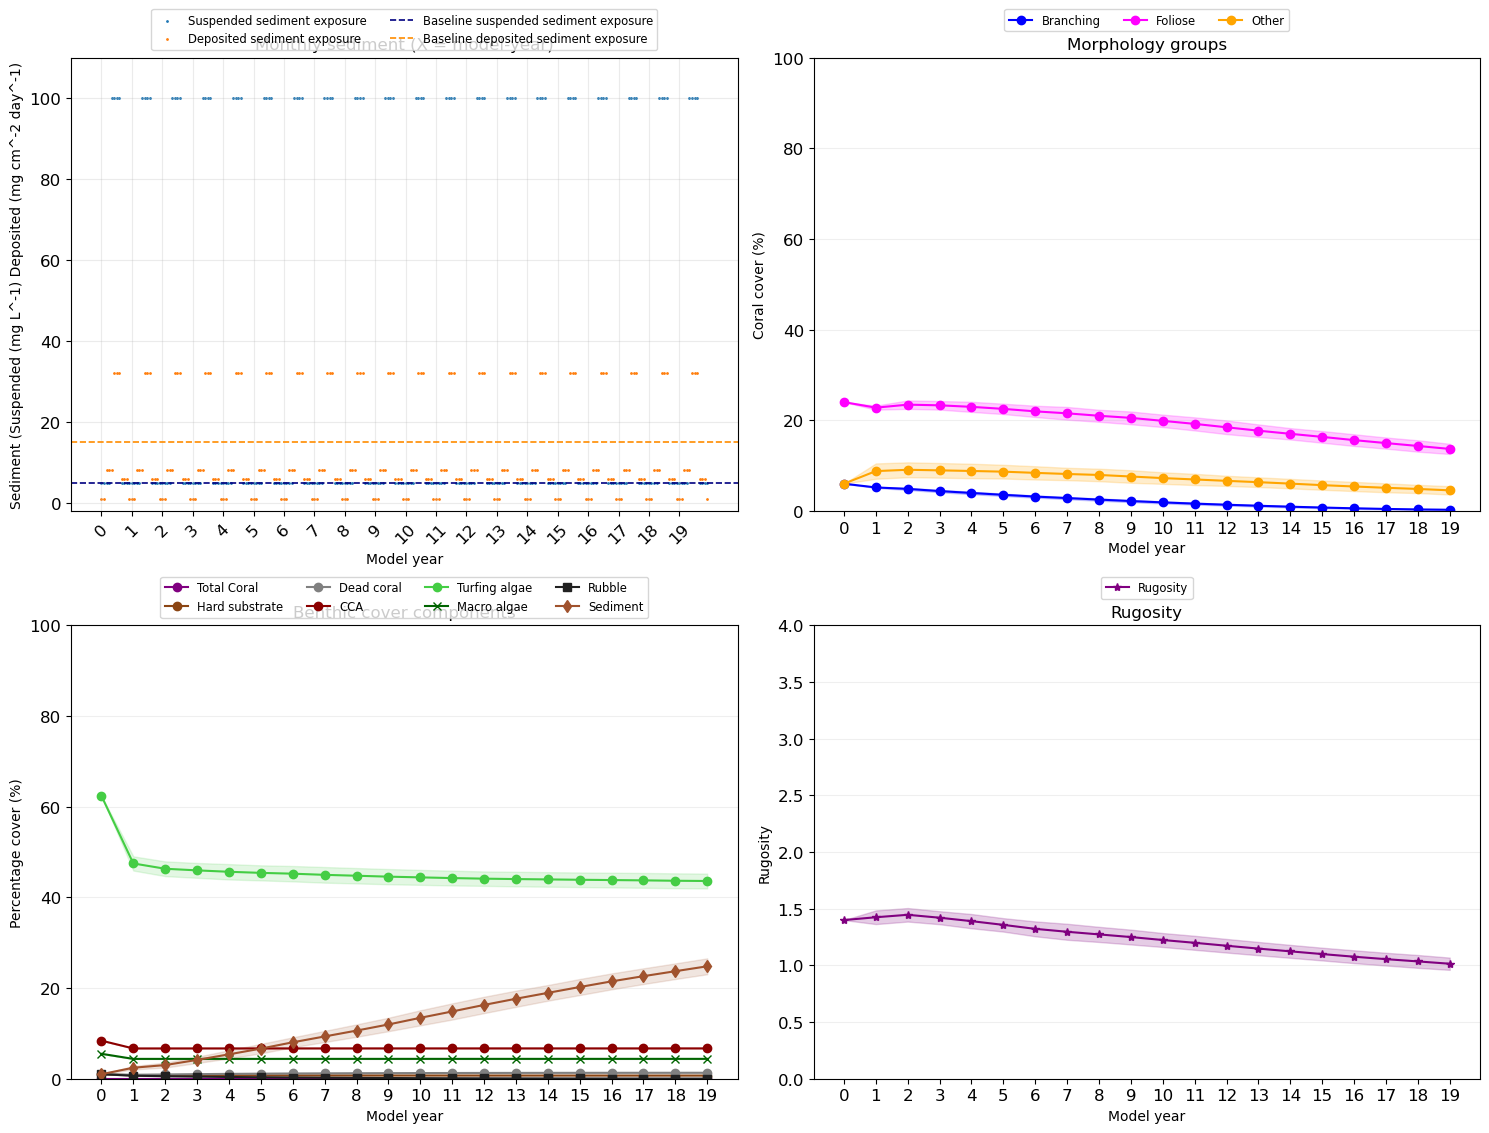

In [19]:
#
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MaxYear = int(globals().get('MaxYear', 20))
year_start = int(globals().get('year_start', 0))

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

model_x = np.arange(0, MaxYear + 1)               # model-year indices (0..MaxYear)

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# --- Plot 1: Monthly sediment (X=model-year with month offset, Y=sediment) as lines (no dots) ---
ax = axs[0, 0]
sedi_src = globals().get('sedi_years', {}) or globals().get('sediment_df', {})
baseline_suspended = float(globals().get('baseline_suspended_sediment', 0))
baseline_deposited = float(globals().get('baseline_deposited_sediment', 0))

pts = []
if isinstance(sedi_src, dict):
    for k, v in sedi_src.items():
        try:
            # support tuple/list keys (rel_year, month)
            if isinstance(k, (tuple, list)) and len(k) >= 2:
                ry = int(k[0]); m = int(k[1])
            else:
                continue
            if isinstance(v, (list, tuple)) and len(v) >= 2:
                suspended = float(v[0]); deposited = float(v[1])
            elif isinstance(v, dict):
                suspended = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                deposited = float(v.get('Deposited_sediment', v.get('deposited', 0)))
            else:
                suspended = float(v); deposited = 0.0
        except Exception:
            continue
        if 0 <= ry <= MaxYear:
            xpos = ry + (m - 1) / 12.0
            pts.append((xpos, suspended, deposited))

if not pts:
    ax.text(0.5, 0.5, "No monthly sediment data", ha='center', va='center', transform=ax.transAxes)
else:
    # sort by x to ensure a sensible line plot
    pts.sort(key=lambda p: p[0])
    xs = [p[0] for p in pts]
# ensure legend containers exist before appending
handles_all = globals().get('handles_all', [])
labels_all  = globals().get('labels_all', [])

# existing code that builds pts, creates h1/h2, etc.
suspended_y = [p[1] for p in pts]
deposited_y = [p[2] for p in pts]

h1 = ax.scatter(xs, suspended_y, color='tab:blue', s=1, label='Suspended sediment exposure')
h2 = ax.scatter(xs, deposited_y, color='tab:orange', s=1, label='Deposited sediment exposure')
ax.axhline(baseline_suspended, color='navy', linestyle='--', linewidth=1.2, label='Baseline suspended sediment exposure')
ax.axhline(baseline_deposited, color='darkorange', linestyle='--', linewidth=1.2, label='Baseline deposited sediment exposure')

handles_all += [h1, h2]
labels_all  += ['Suspended (monthly)', 'Deposited (monthly)']

ax.set_xlabel('Model year')
# { changed code }
ax.set_ylabel('Suspended sediment (mg L^-1)  —  Deposited sediment (mg cm^-2 day^-1)')


    # place legend above this subplot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, fontsize='small')

ax.set_xlabel('Model year')
ax.set_ylabel('Sediment (Suspended (mg L^-1) Deposited (mg cm^-2 day^-1)')
ax.set_title('Monthly sediment (X = model-year)')
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.set_ylim(-2, 110)   # upper bound fixed to 110
ax.grid(alpha=0.25)

# --- Plot 2: Morphology groups (X=model-year indices, Y=cover %) with SD shading ---
ax = axs[0, 1]
final_df = globals().get('final_df', None)

def mean_std_for(col):
    if isinstance(final_df, pd.DataFrame) and col in final_df.columns:
        s_mean = final_df.groupby('Year')[col].mean().reindex(model_x, fill_value=0).values
        s_std  = final_df.groupby('Year')[col].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        s_mean = np.zeros_like(model_x, dtype=float)
        s_std = np.zeros_like(model_x, dtype=float)
    return s_mean, s_std

b_mean, b_std = mean_std_for('Branching_Area (%)')
f_mean, f_std = mean_std_for('Foliose_Area (%)')
o_mean, o_std = mean_std_for('Other_Area (%)')

hl_b, = ax.plot(model_x, b_mean, '-o', color='blue', label='Branching')
ax.fill_between(model_x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.2)
hl_f, = ax.plot(model_x, f_mean, '-o', color='fuchsia', label='Foliose')
ax.fill_between(model_x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.2)
hl_o, = ax.plot(model_x, o_mean, '-o', color='orange', label='Other')
ax.fill_between(model_x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.2)

ax.set_xlabel('Model year')
ax.set_ylabel('Coral cover (%)')
ax.set_title('Morphology groups')
ax.set_ylim(0, 100)
ax.set_xticks(model_x)
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, fontsize='small')

# --- Plot 3: Benthic components (X=model-year indices, Y=%) with SD shading ---
ax = axs[1, 0]

def mean_std_from_df(df, col):
    if isinstance(df, pd.DataFrame) and col in df.columns:
        m = df.groupby('Year')[col].mean().reindex(model_x, fill_value=0).values
        s = df.groupby('Year')[col].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        m = np.zeros_like(model_x, dtype=float)
        s = np.zeros_like(model_x, dtype=float)
    return m, s

total_m, total_s = mean_std_from_df(final_df, 'Total_Coral_Cover (%)')
hs_m, hs_s       = mean_std_from_df(final_df, 'hard_substrate (%)')
dc_m, dc_s       = mean_std_from_df(final_df, 'dead_coral (%)')
cca_m, cca_s     = mean_std_from_df(final_df, 'CCA (%)')
tf_m, tf_s       = mean_std_from_df(final_df, 'turfing_algae (%)')
ma_m, ma_s       = mean_std_from_df(final_df, 'macro_algae (%)')
rb_m, rb_s       = mean_std_from_df(final_df, 'rubble (%)')
sed_m, sed_s     = mean_std_from_df(final_df, 'sediment (%)')

lines = []
lines.append(ax.plot(model_x, total_m, label='Total Coral', color='purple', marker='o')[0])
ax.fill_between(model_x, total_m - total_s, total_m + total_s, color='purple', alpha=0.15)
lines.append(ax.plot(model_x, hs_m, label='Hard substrate', color='saddlebrown', marker='o')[0])
ax.fill_between(model_x, hs_m - hs_s, hs_m + hs_s, color='saddlebrown', alpha=0.15)
lines.append(ax.plot(model_x, dc_m, label='Dead coral', color='gray', marker='o')[0])
ax.fill_between(model_x, dc_m - dc_s, dc_m + dc_s, color='gray', alpha=0.15)
lines.append(ax.plot(model_x, cca_m, label='CCA', color='#8B0000', marker='o')[0])
ax.fill_between(model_x, cca_m - cca_s, cca_m + cca_s, color='#8B0000', alpha=0.15)
lines.append(ax.plot(model_x, tf_m, label='Turfing algae', color='#44CD44', marker='o')[0])
ax.fill_between(model_x, tf_m - tf_s, tf_m + tf_s, color="#44CD44", alpha=0.15)
lines.append(ax.plot(model_x, ma_m, label='Macro algae', color='darkgreen', marker='x')[0])
ax.fill_between(model_x, ma_m - ma_s, ma_m + ma_s, color='darkgreen', alpha=0.15)
lines.append(ax.plot(model_x, rb_m, label='Rubble', color='#212121', marker='s')[0])
ax.fill_between(model_x, rb_m - rb_s, rb_m + rb_s, color='#212121', alpha=0.15)
lines.append(ax.plot(model_x, sed_m, label='Sediment', color='sienna', marker='d')[0])
ax.fill_between(model_x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)

ax.set_xlabel('Model year')
ax.set_ylabel('Percentage cover (%)')
ax.set_title('Benthic cover components')
ax.set_xticks(model_x)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, fontsize='small')

# --- Plot 4: Rugosity (X=model-year indices, Y=rugosity) with SD if available (purple) ---
ax = axs[1, 1]
if isinstance(final_df, pd.DataFrame) and 'Rugosity' in final_df.columns:
    rug_mean = final_df.groupby('Year')['Rugosity'].mean().reindex(model_x, fill_value=np.nan).values
    rug_std  = final_df.groupby('Year')['Rugosity'].std().reindex(model_x, fill_value=0).fillna(0).values
else:
    try:
        if 'get_rugosity_list' in globals():
            rl = list(globals()['get_rugosity_list']())
            rl = (rl + [globals().get('Initial_Rugosity', 0.0)] * (MaxYear + 1))[:MaxYear+1]
            rug_mean = np.array(rl, dtype=float)
            rug_std = np.zeros_like(rug_mean)
        else:
            rug_mean = np.zeros_like(model_x, dtype=float) + float(globals().get('Initial_Rugosity', 0.0))
            rug_std = np.zeros_like(rug_mean)
    except Exception:
        rug_mean = np.zeros_like(model_x, dtype=float) + float(globals().get('Initial_Rugosity', 0.0))
        rug_std = np.zeros_like(rug_mean)

h_rug, = ax.plot(model_x, rug_mean, '-*', color='purple', label='Rugosity')
ax.fill_between(model_x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.2)
ax.set_xlabel('Model year')
ax.set_ylabel('Rugosity')
ax.set_title('Rugosity')
ax.set_xticks(model_x)
ax.set_ylim(0, max(4.0, np.nanmax(rug_mean) + 0.5))
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=1, fontsize='small')

# layout and save (PNG / PDF / SVG)
plt.tight_layout(rect=[0, 0, 1, 0.95])
basename = f'{title}2x2'
for ext in ('png', 'pdf', 'svg'):
    outpath = os.path.join(graph_dir, f"{basename}.{ext}")
    fig.savefig(outpath, dpi=200)
print(f"Saved figures to: {graph_dir} as {basename}.png/.pdf/.svg")
#

Saved figures to: output/figures as Scenario1.1ClearwaterReef TEST_1x4.png/.pdf/.svg


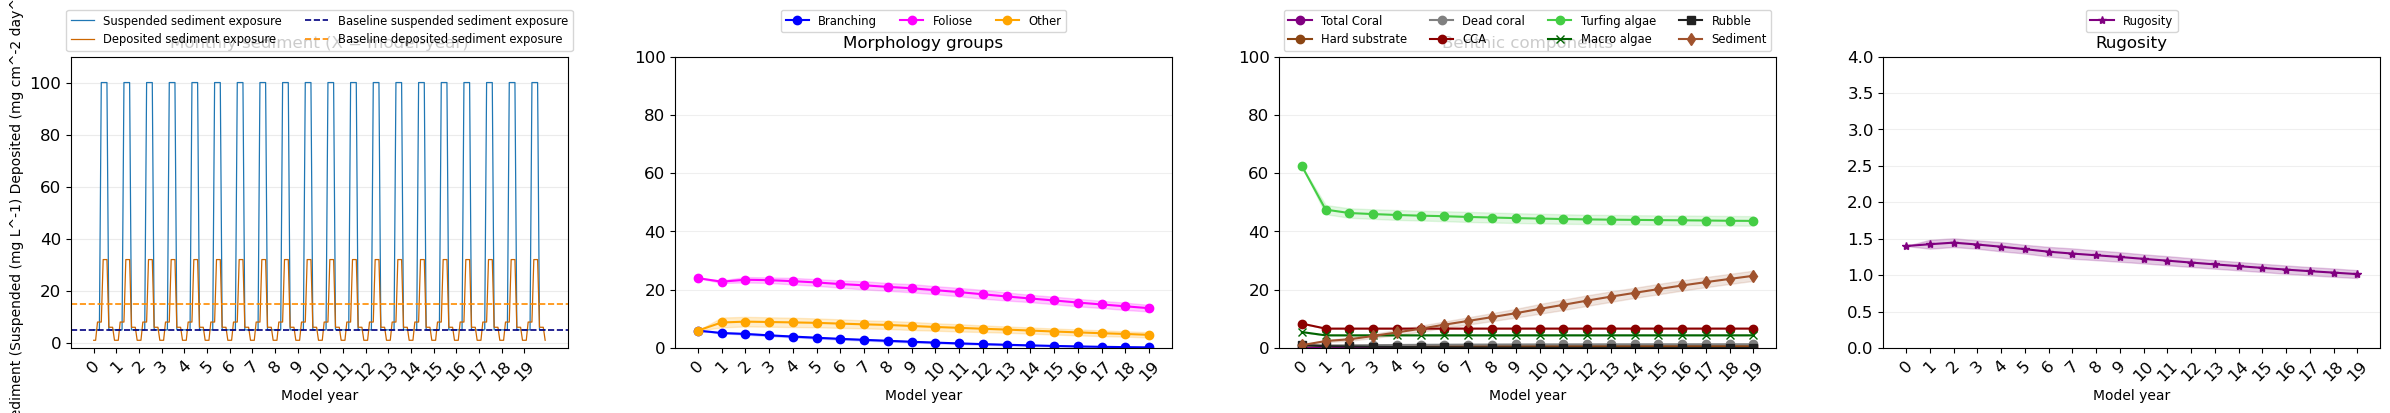

In [20]:
# 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

MaxYear = int(globals().get('MaxYear', 20))
year_start = int(globals().get('year_start', 0))

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

model_x = np.arange(0, MaxYear + 1)
actual_years = model_x + year_start

fig, axs = plt.subplots(1, 4, figsize=(24, 5), sharey=False)
# ensure axs is iterable when ncols==1
if not hasattr(axs, "__iter__"):
    axs = [axs]

# --- Plot 1: Monthly sediment (X = model-year with month offset) ---
ax = axs[0]
sedi_src = globals().get('sedi_years', {}) or globals().get('sediment_df', {})
baseline_suspended = float(globals().get('baseline_suspended_sediment', 0))
baseline_deposited = float(globals().get('baseline_deposited_sediment', 0))

pts = []
if isinstance(sedi_src, dict):
    for k, v in sedi_src.items():
        try:
            if isinstance(k, (tuple, list)) and len(k) >= 2:
                ry = int(k[0]); m = int(k[1])
            else:
                continue
            if isinstance(v, (list, tuple)) and len(v) >= 2:
                suspended = float(v[0]); deposited = float(v[1])
            elif isinstance(v, dict):
                suspended = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                deposited = float(v.get('Deposited_sediment', v.get('deposited', 0)))
            else:
                suspended = float(v); deposited = 0.0
        except Exception:
            continue
        if 0 <= ry <= MaxYear:
            xpos = ry + (m - 1) / 12.0
            pts.append((xpos, suspended, deposited))

plot1_handles = []
plot1_labels = []
if not pts:
    ax.text(0.5, 0.5, "No monthly sediment data", ha='center', va='center', transform=ax.transAxes)
else:
    pts.sort(key=lambda p: p[0])
    xs = [p[0] for p in pts]
    suspended_y = [p[1] for p in pts]
    deposited_y = [p[2] for p in pts]

    # 
    h1, = ax.plot(xs, suspended_y, color='tab:blue', linewidth=0.9, label='Suspended sediment exposure')
    h2, = ax.plot(xs, deposited_y, color='#CC6600', linewidth=0.9, label='Deposited sediment exposure') 
    # baseline horizontal lines with updated labels
    hb = ax.axhline(baseline_suspended, color='navy', linestyle='--', linewidth=1.2, label='Baseline suspended sediment exposure')
    hd = ax.axhline(baseline_deposited, color='darkorange', linestyle='--', linewidth=1.2, label='Baseline deposited sediment exposure')

    plot1_handles += [h1, h2, hb, hd]
    plot1_labels  = [h.get_label() for h in plot1_handles]

# IMPORTANT: x-axis should be model-year indices (not actual calendar years)
ax.set_xlabel('Model year')
ax.set_ylabel('Sediment (Suspended (mg L^-1) Deposited (mg cm^-2 day^-1)')  # per request
ax.set_title('Monthly sediment (X = model-year)')
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.set_ylim(-2, 110)
ax.grid(axis='y', alpha=0.25)
# legend above this axis
if plot1_handles:
    ax.legend(plot1_handles, plot1_labels, loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize='small')

# --- Plot 2: Morphology groups (X = model_x) ---
ax = axs[1]
final_df = globals().get('final_df', None)

def mean_std_for(col):
    if isinstance(final_df, pd.DataFrame) and col in final_df.columns:
        s_mean = final_df.groupby('Year')[col].mean().reindex(model_x, fill_value=0).values
        s_std  = final_df.groupby('Year')[col].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        s_mean = np.zeros_like(model_x, dtype=float)
        s_std = np.zeros_like(model_x, dtype=float)
    return s_mean, s_std

b_mean, b_std = mean_std_for('Branching_Area (%)')
f_mean, f_std = mean_std_for('Foliose_Area (%)')
o_mean, o_std = mean_std_for('Other_Area (%)')

hl_b, = ax.plot(model_x, b_mean, '-o', color='blue', label='Branching')
ax.fill_between(model_x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.2)
hl_f, = ax.plot(model_x, f_mean, '-o', color='fuchsia', label='Foliose')
ax.fill_between(model_x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.2)
hl_o, = ax.plot(model_x, o_mean, '-o', color='orange', label='Other')
ax.fill_between(model_x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.2)

ax.set_xlabel('Model year')
ax.set_title('Morphology groups')
ax.set_ylim(0, 100)
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.grid(axis='y', alpha=0.2)
# legend above this axis
ax.legend([hl_b, hl_f, hl_o], ['Branching','Foliose','Other'], loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=3, fontsize='small')

# --- Plot 3: Benthic components ---
ax = axs[2]
def mean_std_from_df(df, col):
    if isinstance(df, pd.DataFrame) and col in df.columns:
        m = df.groupby('Year')[col].mean().reindex(model_x, fill_value=0).values
        s = df.groupby('Year')[col].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        m = np.zeros_like(model_x, dtype=float)
        s = np.zeros_like(model_x, dtype=float)
    return m, s

total_m, total_s = mean_std_from_df(final_df, 'Total_Coral_Cover (%)')
hs_m, hs_s       = mean_std_from_df(final_df, 'hard_substrate (%)')
dc_m, dc_s       = mean_std_from_df(final_df, 'dead_coral (%)')
cca_m, cca_s     = mean_std_from_df(final_df, 'CCA (%)')
tf_m, tf_s       = mean_std_from_df(final_df, 'turfing_algae (%)')
ma_m, ma_s       = mean_std_from_df(final_df, 'macro_algae (%)')
rb_m, rb_s       = mean_std_from_df(final_df, 'rubble (%)')
sed_m, sed_s     = mean_std_from_df(final_df, 'sediment (%)')

lines = []
lines.append(ax.plot(model_x, total_m, label='Total Coral', color='purple', marker='o')[0])
ax.fill_between(model_x, total_m - total_s, total_m + total_s, color='purple', alpha=0.15)
lines.append(ax.plot(model_x, hs_m, label='Hard substrate', color='saddlebrown', marker='o')[0])
ax.fill_between(model_x, hs_m - hs_s, hs_m + hs_s, color='saddlebrown', alpha=0.15)
lines.append(ax.plot(model_x, dc_m, label='Dead coral', color='gray', marker='o')[0])
ax.fill_between(model_x, dc_m - dc_s, dc_m + dc_s, color='gray', alpha=0.15)
lines.append(ax.plot(model_x, cca_m, label='CCA', color='#8B0000', marker='o')[0])
ax.fill_between(model_x, cca_m - cca_s, cca_m + cca_s, color='#8B0000', alpha=0.15)
lines.append(ax.plot(model_x, tf_m, label='Turfing algae', color='#44CD44', marker='o')[0])
ax.fill_between(model_x, tf_m - tf_s, tf_m + tf_s, color="#44CD44", alpha=0.15)
lines.append(ax.plot(model_x, ma_m, label='Macro algae', color='darkgreen', marker='x')[0])
ax.fill_between(model_x, ma_m - ma_s, ma_m + ma_s, color='darkgreen', alpha=0.15)
lines.append(ax.plot(model_x, rb_m, label='Rubble', color='#212121', marker='s')[0])
ax.fill_between(model_x, rb_m - rb_s, rb_m + rb_s, color='#212121', alpha=0.15)
lines.append(ax.plot(model_x, sed_m, label='Sediment', color='sienna', marker='d')[0])
ax.fill_between(model_x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)

ax.set_xlabel('Model year')
ax.set_title('Benthic components')
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.2)
# legend above this axis (wrap across columns)
ax.legend(lines, ['Total Coral','Hard substrate','Dead coral','CCA','Turfing algae','Macro algae','Rubble','Sediment'],
          loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=4, fontsize='small')

# --- Plot 4: Rugosity ---
ax = axs[3]
if isinstance(final_df, pd.DataFrame) and 'Rugosity' in final_df.columns:
    rug_mean = final_df.groupby('Year')['Rugosity'].mean().reindex(model_x, fill_value=np.nan).values
    rug_std  = final_df.groupby('Year')['Rugosity'].std().reindex(model_x, fill_value=0).fillna(0).values
else:
    try:
        if 'get_rugosity_list' in globals():
            rl = list(globals()['get_rugosity_list']())
            rl = (rl + [globals().get('Initial_Rugosity', 0.0)] * (MaxYear + 1))[:MaxYear+1]
            rug_mean = np.array(rl, dtype=float)
            rug_std = np.zeros_like(rug_mean)
        else:
            rug_mean = np.zeros_like(model_x, dtype=float) + float(globals().get('Initial_Rugosity', 0.0))
            rug_std = np.zeros_like(rug_mean)
    except Exception:
        rug_mean = np.zeros_like(model_x, dtype=float) + float(globals().get('Initial_Rugosity', 0.0))
        rug_std = np.zeros_like(rug_mean)

h_rug, = ax.plot(model_x, rug_mean, '-*', color='purple', label='Rugosity')
ax.fill_between(model_x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.2)
ax.set_xlabel('Model year')
ax.set_title('Rugosity')
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.set_ylim(0, max(4.0, np.nanmax(rug_mean) + 0.5))
ax.grid(axis='y', alpha=0.2)
# legend above this axis
ax.legend([h_rug], ['Rugosity'], loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=1, fontsize='small')

# adjust layout to allow space for all per-axis legends above plots
plt.tight_layout(rect=[0, 0, 1, 0.88])

basename = f'{title}_1x4'
for ext in ('png', 'pdf', 'svg'):
    outpath = os.path.join(graph_dir, f"{basename}.{ext}")
    fig.savefig(outpath, dpi=200)

print(f"Saved figures to: {graph_dir} as {basename}.png/.pdf/.svg")
plt.show()
#

In [21]:
import winsound
winsound.Beep(1000, 2000)  # 1000 Hz for 200 ms